<a href="https://colab.research.google.com/github/anushah-200/factcheckAI/blob/main/notebooks/11_model_validation_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

sns.set_style("whitegrid")

In [6]:
base_path = "/content/drive/MyDrive/factcheckAI/outputs/"

In [7]:
X_train = pd.read_csv(
    base_path+"X_train.csv"
)

X_test = pd.read_csv(
    base_path+"X_test.csv"
)

y_train = pd.read_csv(
    base_path+"y_train.csv"
).squeeze()


y_test = pd.read_csv(
    base_path+"y_test.csv"
).squeeze()

In [8]:
#checking
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(644, 7)
(162, 7)
(644,)
(162,)


In [9]:
#verifying features
X_train.columns

Index(['Category', 'Type', 'Model', 'ResponseLength', 'QuestionLength',
       'ResponseCharacters', 'AverageWordLength'],
      dtype='object')

In [10]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)


logistic_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [11]:
logistic_pred = logistic_model.predict(
    X_test
)


logistic_prob = logistic_model.predict_proba(
    X_test
)[:,1]

In [12]:
#evaluation function
def evaluate_model(name, y_true, y_pred, y_prob):

    print(name)

    print(
        classification_report(
            y_true,
            y_pred
        )
    )


    print(
        "ROC-AUC:",
        roc_auc_score(
            y_true,
            y_prob
        )
    )

In [13]:
evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.71      0.53      0.60        74
         1.0       0.67      0.82      0.74        88

    accuracy                           0.69       162
   macro avg       0.69      0.67      0.67       162
weighted avg       0.69      0.69      0.68       162

ROC-AUC: 0.7076167076167076


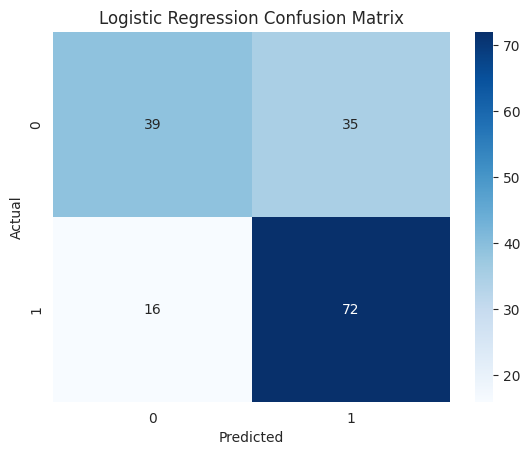

In [14]:
cm = confusion_matrix(
    y_test,
    logistic_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [15]:
tree = DecisionTreeClassifier(
    random_state=42
)


tree.fit(
    X_train,
    y_train
)


tree_pred = tree.predict(
    X_test
)


tree_prob = tree.predict_proba(
    X_test
)[:,1]

In [16]:
evaluate_model(
    "Decision Tree",
    y_test,
    tree_pred,
    tree_prob
)

Decision Tree
              precision    recall  f1-score   support

         0.0       0.83      0.73      0.78        74
         1.0       0.79      0.88      0.83        88

    accuracy                           0.81       162
   macro avg       0.81      0.80      0.80       162
weighted avg       0.81      0.81      0.81       162

ROC-AUC: 0.8023648648648649


In [17]:
forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


forest.fit(
    X_train,
    y_train
)


forest_pred = forest.predict(
    X_test
)


forest_prob = forest.predict_proba(
    X_test
)[:,1]

In [18]:
evaluate_model(
    "Random Forest",
    y_test,
    forest_pred,
    forest_prob
)

Random Forest
              precision    recall  f1-score   support

         0.0       0.87      0.80      0.83        74
         1.0       0.84      0.90      0.87        88

    accuracy                           0.85       162
   macro avg       0.85      0.85      0.85       162
weighted avg       0.85      0.85      0.85       162

ROC-AUC: 0.9207616707616708


In [19]:
#comparison models
results=[]


models = [
    (
        "Logistic Regression",
        logistic_pred,
        logistic_prob
    ),

    (
        "Decision Tree",
        tree_pred,
        tree_prob
    ),

    (
        "Random Forest",
        forest_pred,
        forest_prob
    )
]


for name,pred,prob in models:

    results.append({

        "Model":name,

        "Accuracy":
        accuracy_score(
            y_test,
            pred
        ),

        "Precision":
        precision_score(
            y_test,
            pred
        ),

        "Recall":
        recall_score(
            y_test,
            pred
        ),

        "F1":
        f1_score(
            y_test,
            pred
        ),

        "ROC-AUC":
        roc_auc_score(
            y_test,
            prob
        )
    })


results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.685185,0.672897,0.818182,0.738462,0.707617
1,Decision Tree,0.808642,0.793814,0.875000,0.832432,0.802365
2,Random Forest,0.851852,0.840426,0.897727,0.868132,0.920762


In [20]:
#saving
results_df.to_csv(
    base_path+"validated_model_comparison.csv",
    index=False
)

In [21]:
#error analysis
#using random forest as final model
error_analysis = X_test.copy()


error_analysis["Actual"] = y_test.values


error_analysis["Predicted"] = forest_pred


error_analysis["Error"] = (
    error_analysis["Actual"]
    !=
    error_analysis["Predicted"]
)


error_analysis.head()

,Category,Type,Model,ResponseLength,QuestionLength,ResponseCharacters,AverageWordLength,Actual,Predicted,Error
0,-0.233168,-1.061437,-0.013531,0.225811,-0.891475,0.320624,0.446915,1.0,1.0,False
1,-0.639950,0.942119,1.198242,2.153944,-0.011464,1.827807,-0.529078,1.0,1.0,False
2,0.377005,0.942119,1.198242,2.446085,-0.304801,2.224909,-0.244189,1.0,1.0,False
3,-0.843340,-1.061437,-1.225303,-0.007902,-0.158133,-0.004277,0.041369,1.0,1.0,False
4,0.071919,-1.061437,1.198242,0.810094,0.135204,0.573325,-0.648675,1.0,1.0,False


In [22]:
error_analysis.to_csv(
    base_path+"error_analysis_day11.csv",
    index=False
)

In [23]:
errors = error_analysis[
    error_analysis["Error"]==True
]


print(
    "Total Errors:",
    len(errors)
)

Total Errors: 24


In [24]:
#false positives
false_positive = error_analysis[
    (error_analysis["Actual"]==0)
    &
    (error_analysis["Predicted"]==1)
]


print(
    "False Positives:",
    len(false_positive)
)

False Positives: 15


In [25]:
false_positive.to_csv(
    base_path+"false_positive_day11.csv",
    index=False
)

In [26]:
#false negatives
false_negative = error_analysis[
    (error_analysis["Actual"]==1)
    &
    (error_analysis["Predicted"]==0)
]


print(
    "False Negatives:",
    len(false_negative)
)

False Negatives: 9


In [27]:
false_negative.to_csv(
    base_path+"false_negative_day11.csv",
    index=False
)

In [28]:
#feature importance
importance = pd.DataFrame({

    "Feature":
    X_train.columns,

    "Importance":
    forest.feature_importances_

})


importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Category,0.311537
5,ResponseCharacters,0.172587
4,QuestionLength,0.166926
6,AverageWordLength,0.147686
3,ResponseLength,0.135600
2,Model,0.036882
1,Type,0.028781


In [29]:
importance.to_csv(
    base_path+"validated_feature_importance.csv",
    index=False
)